<a href="https://colab.research.google.com/github/PujanPandey07/Deep-Learning-/blob/main/MLP/Multiclassclassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Multi Class Classification using Neural Networks

In [27]:
import torch
import numpy as np
import torch.nn as nn
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [28]:
Num_classes=4
num_features=2
X_blob,y_blob=make_blobs(n_samples=1000,n_features=num_features,centers=Num_classes,cluster_std=1.5,random_state=1)

In [29]:
#changing data into cuda compatible format
X_blob=torch.from_numpy(X_blob).type(torch.float)
y_blob=torch.from_numpy(y_blob).type(torch.long)

In [30]:
# Split into training and test Data
X_train, X_test, y_train, y_test = train_test_split(X_blob, y_blob, test_size=0.2, random_state=1)

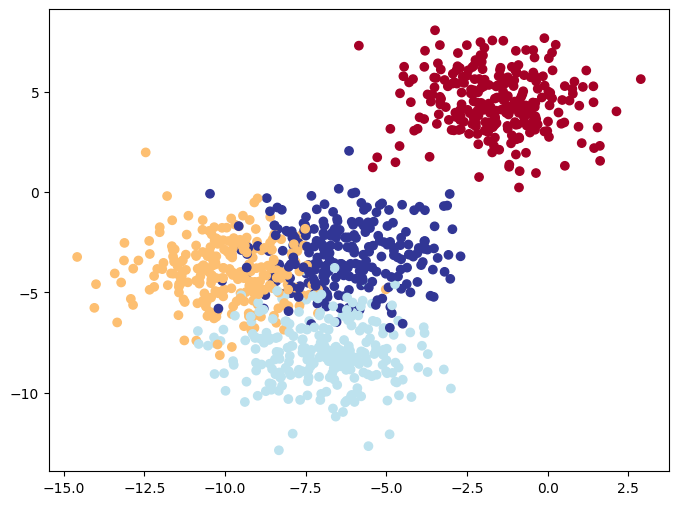

In [31]:
# visualize
plt.figure(figsize=(8, 6))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap=plt.cm.RdYlBu)

In [32]:
# Building The MUlti_class_Classification Model
device="cuda" if torch.cuda.is_available() else "cpu"
class Blob_classify(nn.Module):
  def __init__(self,num_features=2,num_classes=4,hidden_units=8):
    self.num_features=num_features
    self.num_classes=num_classes
    self.hidden_units=hidden_units
    super().__init__()
    self.linear_layer_stack=nn.Sequential(nn.Linear(in_features=self.num_features,out_features=self.hidden_units),nn.ReLU(),nn.Linear(in_features=self.hidden_units,out_features=self.hidden_units),nn.ReLU(),nn.Linear(in_features=self.hidden_units,out_features=self.num_classes))

  def forward(self,x:torch.Tensor):
    return self.linear_layer_stack(x)
Model_0=Blob_classify()

In [39]:
# creatingloss function and optimizer
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(params=Model_0.parameters(),lr=0.001)

In [40]:
# Building the training loop
epochs=1000
for epoch in range(epochs):
  Model_0.train()
  y_logits=Model_0(X_train)
  y_pred=torch.softmax(y_logits,dim=1).argmax(dim=1)
  loss=loss_fn(y_logits,y_train)
  acc=torch.eq(y_pred,y_train).sum().item()/len(y_train)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  Model_0.eval()
  with torch.inference_mode():

    test_logits=Model_0(X_test)
    test_pred=torch.softmax(test_logits,dim=1).argmax(dim=1)
    test_loss=loss_fn(test_logits,y_test)
    test_acc=torch.eq(test_pred,y_test).sum().item()/len(y_test)

  # print whats happening
  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f} | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}")


Epoch: 0 | Loss: 0.41983, Acc: 0.82 | Test Loss: 0.39205, Test Acc: 0.85
Epoch: 10 | Loss: 0.41976, Acc: 0.82 | Test Loss: 0.39199, Test Acc: 0.85
Epoch: 20 | Loss: 0.41969, Acc: 0.82 | Test Loss: 0.39192, Test Acc: 0.85
Epoch: 30 | Loss: 0.41962, Acc: 0.82 | Test Loss: 0.39186, Test Acc: 0.85
Epoch: 40 | Loss: 0.41954, Acc: 0.82 | Test Loss: 0.39179, Test Acc: 0.85
Epoch: 50 | Loss: 0.41947, Acc: 0.82 | Test Loss: 0.39173, Test Acc: 0.85
Epoch: 60 | Loss: 0.41940, Acc: 0.82 | Test Loss: 0.39167, Test Acc: 0.85
Epoch: 70 | Loss: 0.41933, Acc: 0.82 | Test Loss: 0.39160, Test Acc: 0.85
Epoch: 80 | Loss: 0.41926, Acc: 0.82 | Test Loss: 0.39154, Test Acc: 0.85
Epoch: 90 | Loss: 0.41919, Acc: 0.82 | Test Loss: 0.39147, Test Acc: 0.85
Epoch: 100 | Loss: 0.41912, Acc: 0.82 | Test Loss: 0.39141, Test Acc: 0.85
Epoch: 110 | Loss: 0.41905, Acc: 0.82 | Test Loss: 0.39135, Test Acc: 0.85
Epoch: 120 | Loss: 0.41897, Acc: 0.82 | Test Loss: 0.39128, Test Acc: 0.85
Epoch: 130 | Loss: 0.41890, Acc: 0.8

already exists


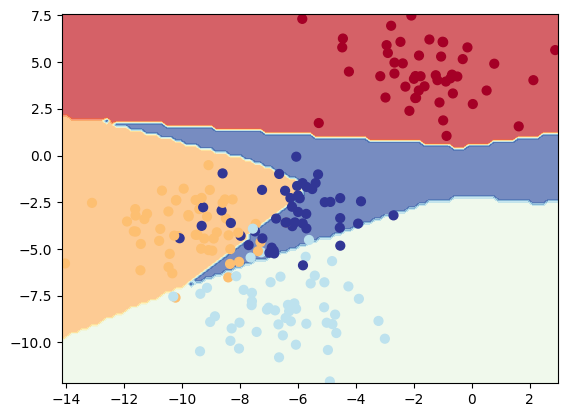

In [41]:
#lets visualize
import requests
from pathlib import Path
if Path("helper_functions.py").is_file():
  print("already exists")
else:
  request=requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py","wb") as f:
    f.write(request.content)
from helper_functions import plot_predictions,plot_decision_boundary
plot_decision_boundary(Model_0,X_test,y_test)


In [42]:
## some more classification metrics
## accuracy
## Recall
## Precision
## classification report

In [45]:
from torchmetrics import Accuracy,Recall,Precision,F1Score
accuracy=Accuracy(task="multiclass",num_classes=Num_classes)
recall=Recall(task="multiclass",num_classes=Num_classes)
precision=Precision(task="multiclass",num_classes=Num_classes)
f1=F1Score(task="multiclass",num_classes=Num_classes)

In [44]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 14.7 MB/s eta 0:00:00


In [47]:
Model_0.eval()
with torch.inference_mode():
  test_logits_final = Model_0(X_test)
  test_pred_final = torch.softmax(test_logits_final, dim=1).argmax(dim=1)

accuracy_value=accuracy(test_pred_final,y_test)
recall_value=recall(test_pred_final,y_test)
precision_value=precision(test_pred_final,y_test)
f1_value=f1(test_pred_final,y_test)
print(f"accuracy: {accuracy_value}")
print(f"recall: {recall_value}")
print(f"precision: {precision_value}")
print(f"f1: {f1_value}")

accuracy: 0.8600000143051147
recall: 0.8600000143051147
precision: 0.8600000143051147
f1: 0.8600000143051147
